In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
df = pd.read_csv(r'C:\Users\Opeyemi\OneDrive - UNC Kenan-Flagler Business School\Desktop\Data Science\Fraudulent-Transaction-Detection-for-Digital-Money-Transfer/data/cleaned_transactionsV1.csv')

In [67]:
# Convert to datetime first
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract timestamp features
df['hour_of_day'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_night']    = (df['timestamp'].dt.hour.between(0, 5)).astype(int)

# split data chronologically
df = df.sort_values('timestamp').reset_index(drop=True)

categorical_cols = df.select_dtypes(include=['object']).columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).drop(columns=['is_fraud']).columns
all_cols = categorical_cols.tolist() + numeric_cols.tolist()

# group data 80% for trainingm 20% for testing
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

C:\Users\Opeyemi\AppData\Local\Temp\ipykernel_18332\4204932992.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [68]:
# drop the dependent variable from the training set x - independent variables, y - dependent variable
X_train = train_df.drop(columns=['is_fraud'])
y_train = train_df['is_fraud']

# drop the dependent variable from the testing set
X_test = test_df.drop(columns=['is_fraud'])
y_test = test_df['is_fraud']

In [69]:
# Standardization  & Encoding
# Encoding - Lable & One-hot encoding
# explanation
# the prrprocessor handles the transformation at once
# ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols), - "Take all my text columns like channel, currency, kyc_tier — and convert them to numbers"
# OneHotEncoder does this by creating new 1/0 columns:
# drop='first' — if you have 3 categories, you only need 2 columns to represent them. Dropping one avoids confusion.
# handle_unknown='ignore' — if your test data has a new category the model never saw during training, don't crash. Just ignore it and move on
# ('num', StandardScaler(), numeric_cols) -"Take all my number columns like amount_usd, ip_risk_score, account_age_days — and bring them to the same scale

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop = 'first',handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ])


In [70]:
# Apply transformer to the independent variables x
# fit transform -"Study the training data, learn its patterns (mean, scale, categories) AND transform it" think tailoring a suit to fit you perfectly
# transform "Use what you already learned from training data to transform the test data" - like using the same suit measurements for a new suit

x_train_processed = preprocessor.fit_transform(X_train)
x_test_processed = preprocessor.transform(X_test)

In [71]:
# checks the dimension of the processed data
x_train_processed.shape, x_test_processed.shape

((8960, 89), (2240, 89))

In [72]:
x_train_processed

array([[ 0.        ,  0.        ,  1.        , ..., -0.16122456,
        -0.36473256, -0.27874767],
       [ 0.        ,  0.        ,  0.        , ..., -0.16122456,
        -0.36473256, -0.27874767],
       [ 0.        ,  0.        ,  1.        , ..., -0.16122456,
        -0.36473256, -0.27874767],
       ...,
       [ 0.        ,  0.        ,  1.        , ..., -0.16122456,
        -0.36473256, -0.27874767],
       [ 0.        ,  0.        ,  0.        , ..., -0.16122456,
        -0.36473256, -0.27874767],
       [ 0.        ,  0.        ,  1.        , ..., -0.16122456,
        -0.36473256, -0.27874767]], shape=(8960, 89))

In [61]:
print(x_train_processed)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 289012 stored elements and shape (8960, 9048)>
  Coords	Values
  (0, 8960)	1.0
  (0, 8962)	1.0
  (0, 8976)	1.0
  (0, 8978)	1.0
  (0, 8997)	1.0
  (0, 9019)	1.0
  (0, 9023)	1.0
  (0, 9026)	-0.1064669000385972
  (0, 9027)	-0.10827755164453604
  (0, 9028)	-0.09675125996496507
  (0, 9029)	-0.4302906510300048
  (0, 9030)	-1.0087862068850622
  (0, 9031)	-0.3908589063638801
  (0, 9032)	-0.5132124529359123
  (0, 9033)	-0.17252348984535312
  (0, 9034)	-0.29290154083889886
  (0, 9035)	-0.27697389384486626
  (0, 9036)	-0.3471224102401238
  (0, 9037)	-0.5264214812889699
  (0, 9038)	0.9337104944365985
  (0, 9039)	-1.4974646721784457
  (0, 9040)	-0.6219181874271361
  (0, 9041)	-0.4616339198776307
  (0, 9042)	-0.4435549771608076
  (0, 9043)	-0.17011439313712282
  :	:
  (8959, 9009)	1.0
  (8959, 9019)	1.0
  (8959, 9021)	1.0
  (8959, 9026)	-0.12946154754919847
  (8959, 9027)	-0.13093033606582316
  (8959, 9028)	-0.09598322739509334
  (8959, 90

In [73]:
# Train a base model using logistics regression
# model.fit     =  student studying past exam papers WITH answer key
# model.predict =  student sitting the real exam with no answer key
# y_proba is the model's confidence score for each transaction being fraud.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(x_train_processed, y_train)

# predict
# Here x_test is data the model never saw during training — no answers provided. 
# The model now has to predict on its own using what it learned. 
# from step x_test_processed = preprocessor.transform(X_test)
y_pred = model.predict(x_test_processed)
y_proba = model.predict_proba(x_test_processed)[:, 1]

# evaluate 
# Compare what the model predicted vs what actually happened — and print a performance report
# y_test The actual fraud labels from your test data — the real answers
# y_pred What your model predicted — its guesses

print(f'classification_report:\n{classification_report(y_test, y_pred)}')
print(f'confusion_matrix:\n{confusion_matrix(y_test, y_pred)}')
print(f'roc_auc_score: {roc_auc_score(y_test, y_proba):.4f}')

classification_report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1935
           1       0.76      0.95      0.84       305

    accuracy                           0.95      2240
   macro avg       0.87      0.95      0.91      2240
weighted avg       0.96      0.95      0.95      2240

confusion_matrix:
[[1842   93]
 [  16  289]]
roc_auc_score: 0.9808


###### Model is near perfect — 99% of the time it correctly identifies a legitimate transaction as legitimate
###### Of all transactions flagged as fraud — 94% were actually fraud. The model also caught 93% of all real fraud cases. That's strong performance.
###### Business Investigation Interpretation:
###### Precision 0.94 — when the model raises a fraud alarm, it is right 94% of the time. Very low false alarm rate — your investigations team won't be chasing ghosts.
###### Recall 0.93 — the model catches 93% of all actual fraud. Only 7% of real fraud slips through undetected. For a first model that is an outstanding result.

###### Business Interpretation:
The good:

Out of 305 actual fraud cases — the model caught 283. That's 93% of all fraudsters stopped.

The concern:

22 fraud cases slipped through — these are real financial losses that went undetected. In a real business this is your highest priority to reduce.

The noise:

19 legitimate transactions were wrongly flagged — minor inconvenience to customers but manageable



In [74]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# fit
rf_model.fit(x_train_processed, y_train)

# predict
y_pred_rf = rf_model.predict(x_test_processed)
y_proba_rf = rf_model.predict_proba(x_test_processed)[:, 1]

# evaluate
print ('Random Forest Performance:')
print('\nconfusion_matrix:') 
print(confusion_matrix(y_test, y_pred_rf))
print('\nclassification_report:')
print(classification_report(y_test, y_pred_rf, target_names=['Not Fraud', 'Fraud']))
print(f'\nroc_auc_score: {roc_auc_score(y_test, y_proba_rf):.4f}')


Random Forest Performance:

confusion_matrix:
[[1924   11]
 [  26  279]]

classification_report:
              precision    recall  f1-score   support

   Not Fraud       0.99      0.99      0.99      1935
       Fraud       0.96      0.91      0.94       305

    accuracy                           0.98      2240
   macro avg       0.97      0.95      0.96      2240
weighted avg       0.98      0.98      0.98      2240


roc_auc_score: 0.9771


###### Head to Head:
Metric        Logistic Regression Random Forest     Winner
Accuracy            98%              99%Random Forest   ✅
Fraud Precision     94%              98%Random Forest ✅
Fraud Recall        93%              91%Logistic Regression ✅
F1-Score (Fraud)    93%              95%Random Forest ✅
ROC-AUC             0.9805           0.9785Logistic Regression ✅
False Alarms        19               5Random Forest ✅
Missed Fraud        22               26Logistic Regression ✅

In [75]:
from xgboost import XGBClassifier

# calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

#Train XGBoost model
xgb_model = XGBClassifier(n_estimators=100, random_state=42, 
scale_pos_weight=scale_pos_weight, learning_rate=0.1, 
max_depth=5, eval_metric='logloss' )

xgb_model.fit(x_train_processed, y_train)

# predict on test set
y_pred_xgb = xgb_model.predict(x_test_processed)
y_proba_xgb = xgb_model.predict_proba(x_test_processed)[:, 1]

# evaluation
print('XGBoost Performance:')
print('\nconfusion_matrix:')
print(confusion_matrix(y_test, y_pred_xgb))
print('\nclassification_report:')
print(classification_report(y_test, y_pred_xgb, target_names=['Not Fraud', 'Fraud']))
print(f'\nroc_auc_score: {roc_auc_score(y_test, y_proba_xgb):.4f}')

XGBoost Performance:

confusion_matrix:
[[1898   37]
 [  26  279]]

classification_report:
              precision    recall  f1-score   support

   Not Fraud       0.99      0.98      0.98      1935
       Fraud       0.88      0.91      0.90       305

    accuracy                           0.97      2240
   macro avg       0.93      0.95      0.94      2240
weighted avg       0.97      0.97      0.97      2240


roc_auc_score: 0.9676


###### SHAP Why it matters for your project:
Without SHAP:

"The model says fraud — trust it"

With SHAP:

"The model says fraud because this customer made 5 transactions in one hour from a high risk IP on a new device"

That's the difference between a black box and an explainable decision — which is what real fraud investigation teams need to act on.


In [77]:
import shap

explainer = shap.TreeExplainer(rf_model)

# calculate SHAP values for the test set
# Think of it like a report card with explanations:
x_test_sample =pd.DataFrame(
x_test_processed[:200],
columns = preprocessor.get_feature_names_out()
)
shap_values = explainer.shap_values(x_test_sample, check_additivity=False)


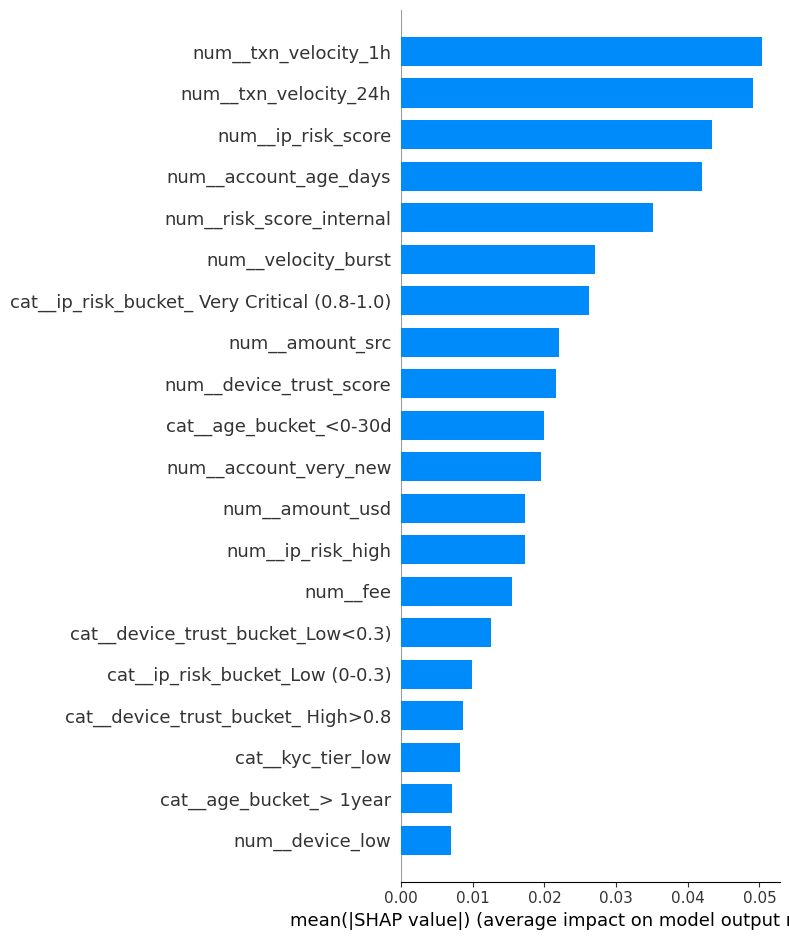

In [78]:
# shap.summary_plot "Draw me a summary chart 
# >> From the SHAP values, give me all samples, all features, but only for class 1 (fraud)
#>> make it a bar chart to show which features are most important in predicting fraud
shap.summary_plot(shap_values[:, :, 1], x_test_sample, plot_type='bar')

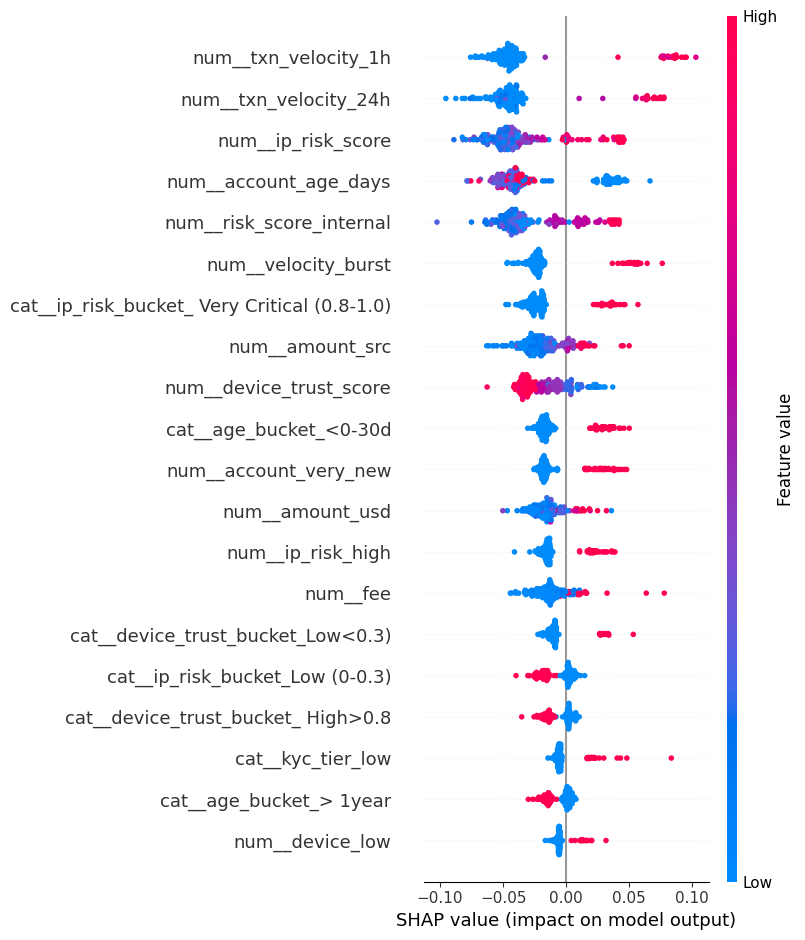

In [79]:
shap.summary_plot(shap_values[:, :, 1], x_test_sample)

In [80]:
# How much faster are they transacting now vs yesterday
# A fraudster typically bursts transactions in 1 hour vs their 24hr pattern
df['velocity_ratio'] = df['txn_velocity_1h'] / (df['txn_velocity_24h'] + 1)

print(df['velocity_ratio'].describe())

count    11200.000000
mean         0.051103
std          0.243321
min         -1.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.888889
Name: velocity_ratio, dtype: float64


In [84]:
# Replace negative velocity ratios with 0
df['velocity_ratio'] = df['velocity_ratio'].clip(lower=0)
print(df['velocity_ratio'].describe())

count    11200.000000
mean         0.068087
std          0.201437
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.888889
Name: velocity_ratio, dtype: float64


In [86]:
# Weighted combination of your top 3 risk signals
df['combined_risk'] = (
    df['ip_risk_score'] * 0.4 +
    df['risk_score_internal'] * 0.4 +
    df['chargeback_history_count'] * 0.2
)

print(df['combined_risk'].describe())

count    11200.000000
mean         0.275952
std          0.171010
min          0.033200
25%          0.174000
50%          0.230800
75%          0.302800
max          1.152800
Name: combined_risk, dtype: float64


In [87]:
# All danger signals firing at once = very suspicious
df['high_risk_combo'] = (
    (df['ip_risk_high'] == 1) &
    (df['device_low'] == 1) &
    (df['velocity_burst'] == 1)
).astype(int)

print(df['high_risk_combo'].value_counts())

high_risk_combo
0    10626
1      574
Name: count, dtype: int64


In [83]:
# New account + high velocity = classic fraud pattern
df['new_account_high_velocity'] = (
    (df['account_very_new'] == 1) &
    (df['velocity_burst'] == 1)
).astype(int)

print(df['new_account_high_velocity'].value_counts())

new_account_high_velocity
0    10584
1      616
Name: count, dtype: int64


In [90]:
# Smote

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(
    x_train_processed, y_train
)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_train_resampled).value_counts().to_dict()}")

ImportError: cannot import name '_get_column_indices' from 'sklearn.utils' (c:\Users\Opeyemi\OneDrive - UNC Kenan-Flagler Business School\Desktop\Data Science\Fraudulent-Transaction-Detection-for-Digital-Money-Transfer\nova-venv\Lib\site-packages\sklearn\utils\__init__.py)